In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import openpyxl as oxl

In [2]:
#butun scrape ve merge olunmus datasetdir
dataset = pd.read_excel('TenderDashboardData2.xlsx')
dataset

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix
0,0,0,303640,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:51:29.7608426,Oğuz şəhəri X.Yunusov 87 ünvanında yerləşən i...,Tenderdə iştirak etmək üçün tender təklifi ver...,Təklif verən malgöndərənlərin sayının 3-dən az...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,29.04.2024 10:00,2500.00,2024-04-29T11:51:29.7608426
1,1,1,300429,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:14:06.2847392,Oğuz şəhərində abadlıq işlərinin layihə smeta ...,Müvafiq icra hakimiyyəti orqanının qərarı əsas...,Müvafiq icra hakimiyyətinin qərarı əsasında,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,12.03.2024 09:00,3500.00,2024-04-29T11:14:06.2847392
2,2,2,302742,DAXİLİ İŞLƏR NAZİRLİYİNİN BAŞ MÜHAFİZƏ İDARƏSİ,2024-04-29T10:44:23.1111078,DİN-in Baş Mühafizə İdarəsinin və tabeçiliyind...,Tenderdə iştirak etmək üçün tender təklifi ver...,DSQ 36.1.1-ci maddəsinin tələblərinə uyğun ola...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 16:00,1017458.23,2024-04-29T10:44:23.1111078
3,3,3,303371,AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ,2024-04-26T17:15:15.7374777,Camaşırların yuyulması xidməti,Tenderdə iştirak etmək üçün tender təklifi ver...,Qanunun 36.1.1-ci maddəsinin tələblərinə uyğun...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 09:30,149811.80,2024-04-26T17:15:15.7374777
4,4,5,302729,“DÖVLƏT MƏŞĞULLUQ AGENTLİYİ“ PUBLİK HÜQUQİ ŞƏXSİ,2024-04-26T16:55:29.660347,"İsmayıllı “DOST EVİ”, Yaradıcılıq, Sərgi və Sa...",Tenderdə iştirak etmək üçün tender təklifi ver...,Azərbaycan Respublikasının Qanununun 36.1.1-ci...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,16.04.2024 15:00,15306.18,2024-04-26T16:55:29.660347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23026,23032,23995,233565,AZƏRBAYCAN RESPUBLİKASI GƏNCLƏR VƏ İDMAN NAZİR...,NaN,Tədbirlərin keşirilməsi,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-31T16:48:52,2019-08-15T11:00:00,NaN,15.08.2019 11:00,NaN,2019-08-15T11:00:00
23027,23033,23996,233520,NİZAMİ RAYON MƏNZİL KOMMUNAL TƏSƏRRÜFATI BİRLİYİ,NaN,Bakı şəhəri Nizami rayonu Bəhruz Nuriyev küçəs...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-30T15:38:15,2019-08-27T16:59:00,NaN,28.08.2019 15:00,NaN,2019-08-27T16:59:00
23028,23034,23997,233480,AZƏRBAYCAN DÖVLƏT BƏDƏN TƏRBİYƏSİ VƏ İDMAN AKA...,NaN,Akademiyanın əsas binasının və İdman zalların...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-29T17:47:47,2019-08-22T15:00:00,NaN,23.08.2019 15:00,NaN,2019-08-22T15:00:00
23029,23035,23998,233424,AZƏRBAYCAN MİLLİ ELMLƏR AKADEMİYASININ AKADEMİ...,NaN,Elmi-tədqiqat işləri üçün materialların alınması,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-26T10:55:14,2019-09-03T11:00:00,NaN,03.09.2019 11:00,NaN,2019-09-03T11:00:00


In [3]:
dataset.shape

(23031, 18)

In [4]:
dataset.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'ID', 'buyerOrganizationName',
       'cancellationDate', 'eventName', 'cancellationOption',
       'cancellationReason', 'tenderin_novu', 'awardedParticipantName',
       'awardedOrganizationPrice', 'finishDate', 'publishDate', 'endDate',
       'awardedParticipantVoen', 'Zərflərin açılış tarixi və vaxtı:',
       'Ehtimal olunan qiymət:', 'tarix'],
      dtype='object')

In [5]:
#her sutunde olan real/non null deyerler
#awardedParticipantVOEN sutunde deyer yoxdur
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23031 entries, 0 to 23030
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0.1                       23031 non-null  int64  
 1   Unnamed: 0                         23031 non-null  int64  
 2   ID                                 23031 non-null  int64  
 3   buyerOrganizationName              23031 non-null  object 
 4   cancellationDate                   3982 non-null   object 
 5   eventName                          23031 non-null  object 
 6   cancellationOption                 2094 non-null   object 
 7   cancellationReason                 3956 non-null   object 
 8   tenderin_novu                      23031 non-null  object 
 9   awardedParticipantName             16268 non-null  object 
 10  awardedOrganizationPrice           16263 non-null  float64
 11  finishDate                         16857 non-null  obj

In [6]:
dataset.describe()

,Unnamed: 0.1,Unnamed: 0,ID,awardedOrganizationPrice,awardedParticipantVoen,Ehtimal olunan qiymət:
count,23031.000000,23031.000000,23031.000000,1.626300e+04,0.0,1.303000e+03
mean,11518.376449,12088.442143,270526.780600,3.442375e+05,NaN,1.251840e+06
std,6649.852779,6907.558655,20438.918958,1.609297e+06,NaN,4.341575e+06
min,0.000000,0.000000,232082.000000,7.774000e+01,NaN,4.673200e+02
25%,5760.500000,6026.500000,253252.500000,5.196256e+04,NaN,7.427025e+04
50%,11519.000000,12281.000000,270968.000000,1.167645e+05,NaN,1.920000e+05
75%,17276.500000,18038.500000,289836.000000,2.569010e+05,NaN,4.891862e+05
max,23036.000000,23999.000000,305000.000000,1.454095e+08,NaN,6.747851e+07


In [7]:
""" 
1. Butun datasetde unique buyerOrganizationName 1158 var; onlardan 560 defe "Baki Metropoliteni Qapali... cixir.
2. Eyni sekilde tarix sutunde unique deyer 22247 var cemi 23031'den, onlardan "2024-05-06T17:00:00" olan tazrix 15 defe var.
3. Tamamlanmis tenderin novu en coxdur, 16857.
4. cancellationOption sutunda "Tenderdə iştirak etmək üçün tender təklifi ver..." en cox cixir, 1253.
5. Onlardan cancellationReason "Müsabiqəyə təklif verən malgöndərənlərin sayı..." 58 dene var, datasetde en cox sayi. 
6. Butun datasetde qalib sirketi "awardedparticipantName" sutunde "İNTELLEKT M.A" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ"dir. 
"""
dataset.describe(include='object')

,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,finishDate,publishDate,endDate,Zərflərin açılış tarixi və vaxtı:,tarix
count,23031,3982,23031,2094,3956,23031,16268,16857,2192,2192,23031,23031
unique,1158,3982,16694,5,3134,3,3712,16852,2191,1413,8980,22247
top,"""Bakı Metropoliteni"" Qapalı Səhmdar Cəmiyyəti",2024-04-29T11:51:29.7608426,Dəftərxana və təsərrüfat mallarının satın alın...,Tenderdə iştirak etmək üçün tender təklifi ver...,Müsabiqəyə təklif verən malgöndərənlərin sayı ...,tamamlanmis_tenderler,"""İNTELLEKT M.A"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",2021-06-22T17:14:39,2024-03-04T14:24:45,2024-05-06T17:00:00,-,2024-05-06T17:00:00
freq,560,1,88,1253,58,16857,154,2,2,15,53,15


In [8]:
"""
1. null deyer sayi datasetde gosterir.
2. awardedParticipantVoen sutununden sonra en cox null deyer Ehtimal olunan qiymət:, 
   cancellationOption ve endDate, finishDate sutunlarindan cixir.
3. Null deyerler Ehtimal olunan qiymət:'nin nisbeten teklif olunan qalib qiymeti "awardedOrganizationPrice"de cox azdir.
"""
dataset.isna().sum()

Unnamed: 0.1                             0
Unnamed: 0                               0
ID                                       0
buyerOrganizationName                    0
cancellationDate                     19049
eventName                                0
cancellationOption                   20937
cancellationReason                   19075
tenderin_novu                            0
awardedParticipantName                6763
awardedOrganizationPrice              6768
finishDate                            6174
publishDate                          20839
endDate                              20839
awardedParticipantVoen               23031
Zərflərin açılış tarixi və vaxtı:        0
Ehtimal olunan qiymət:               21728
tarix                                    0
dtype: int64

In [9]:
#datasetde olan unique deyerler.
dataset.nunique()

Unnamed: 0.1                         23031
Unnamed: 0                           23031
ID                                   23031
buyerOrganizationName                 1158
cancellationDate                      3982
eventName                            16694
cancellationOption                       5
cancellationReason                    3134
tenderin_novu                            3
awardedParticipantName                3712
awardedOrganizationPrice             15134
finishDate                           16852
publishDate                           2191
endDate                               1413
awardedParticipantVoen                   0
Zərflərin açılış tarixi və vaxtı:     8980
Ehtimal olunan qiymət:                1185
tarix                                22247
dtype: int64

Text(0, 0.5, 'Tender qiymeti')

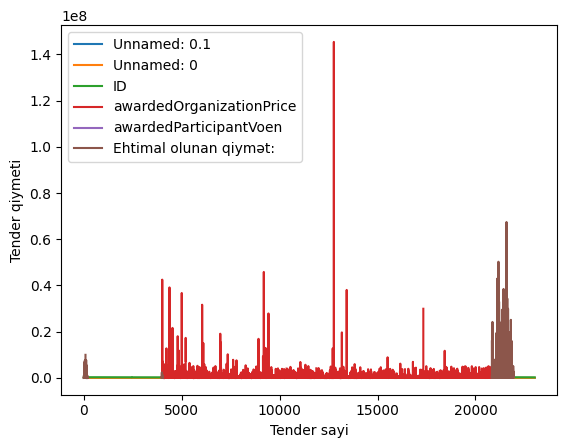

In [10]:
#datasetin umumi plot
#awardedOrganizationPrice sutunden deyer sayi coxdur.

dataset.plot()
plt.xlabel('Tender sayi')
plt.ylabel('Tender qiymeti')

In [11]:
df = pd.DataFrame(dataset)

In [12]:
#Datasetin tender növlərinə görə ayrılması (tamamlanmis tender, davam eden tender & legv eden tender)
def tamamlanmis_filter(data):
    return data[data['tenderin_novu'] == 'tamamlanmis_tenderler']

def legvEden_filter(data):
    return data[data['tenderin_novu'] == 'legv_edilmis']

def davamEden_filter(data):
    return data[data['tenderin_novu'] == 'davam_eden_tenderler']



In [55]:
#tamamlanmis tenderler 
tamamlanmislar = tamamlanmis_filter(df.copy())
tamamlanmislar

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix,iller
3982,3983,4128,300248,NAXÇIVAN MR MELİORASİYA VƏ SU TƏSƏRRÜFATI AÇIQ...,NaN,EÇV nasos hissələri və Mal-materialların satın...,NaN,NaN,tamamlanmis_tenderler,"""KASKAD - HİDRO M"" Məhdud Məsuliyyətli Cəmiyyəti",133735.06,2024-04-26T19:10:18,NaN,NaN,NaN,26.02.2024 17:00,317300.0,2024-04-26T19:10:18,2024
3983,3984,4129,300146,NAXÇIVAN MR MELİORASİYA VƏ SU TƏSƏRRÜFATI AÇIQ...,NaN,nasos hissələri və mal materialların satınalin...,NaN,NaN,tamamlanmis_tenderler,"""ART-PROJE"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",87100.04,2024-04-26T15:23:34,NaN,NaN,NaN,16.02.2024 16:53,200000.0,2024-04-26T15:23:34,2024
3984,3985,4130,300114,AZƏRBAYCAN RESPUBLİKASI BAŞ PROKURORLUĞU,NaN,Tərcümə xidmətlərinin satın alınması,NaN,NaN,tamamlanmis_tenderler,"""SERVICE AND SUPPLY LTD."" Məhdud Məsuliyyətli ...",176800.00,2024-04-26T14:10:20,NaN,NaN,NaN,14.02.2024 17:01,200400.0,2024-04-26T14:10:20,2024
3985,3986,4131,295859,AZƏRBAYCAN RESPUBLİKASININ DÖVLƏT TURİZM AGENT...,NaN,Azərbaycan və İsrail arasında Turizm üzrə İşçi...,NaN,NaN,tamamlanmis_tenderler,NaN,NaN,2024-04-26T14:09:10,NaN,NaN,NaN,30.10.2023 12:00,NaN,2024-04-26T14:09:10,2024
3986,3987,4132,300245,AZƏRBAYCAN RESPUBLİKASI BAŞ PROKURORLUĞU,NaN,Sürətli çap maşını və skaner aparatlarının sat...,NaN,NaN,tamamlanmis_tenderler,"""HALAL-P"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",62265.06,2024-04-26T13:04:42,NaN,NaN,NaN,20.02.2024 17:00,65313.0,2024-04-26T13:04:42,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20834,20838,21600,233099,Azərbaycan Respublikasının Əmək və Əhalinin So...,NaN,Layihələndirmə işləri,NaN,NaN,tamamlanmis_tenderler,"""VIVATECH PROJECT AND CONSULTING"" MƏHDUD MƏSUL...",118552.34,2019-08-08T18:23:34.880505,NaN,NaN,NaN,31.07.2019 15:00,NaN,2019-08-08T18:23:34.880505,2019
20835,20839,21601,233110,AZƏRBAYCAN RESPUBLİKASI TƏHSİL NAZİRLİYİNİN TƏ...,NaN,Təhsil müəssisələrinin təmir-tikintisi üçün la...,NaN,NaN,tamamlanmis_tenderler,AZƏRBAYCAN RESPUBLİKASI FÖVQALƏDƏ HALLAR NAZİR...,115000.00,2019-08-08T12:35:43.4931064,NaN,NaN,NaN,06.08.2019 15:00,NaN,2019-08-08T12:35:43.4931064,2019
20836,20840,21602,232498,"""AZTELEKOM"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",NaN,"KSVPPtr-5e - 1x2x0,52 naqilinin satınalınması",NaN,NaN,tamamlanmis_tenderler,"""TOUCHESS"" Məhdud Məsuliyyətli Cəmiyyəti",663160.00,2019-08-08T11:04:26.0027962,NaN,NaN,NaN,26.07.2019 11:00,NaN,2019-08-08T11:04:26.0027962,2019
20837,20841,21603,233440,AZƏRBAYCAN MİLLİ ELMLƏR AKADEMİYASININ İNFORMA...,NaN,"""Digər maşın və avadanlıqlar"" İTK üzrə avadanl...",NaN,NaN,tamamlanmis_tenderler,"""SOLUTİON"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",291998.08,2019-08-08T09:25:22.8539742,NaN,NaN,NaN,06.08.2019 11:00,NaN,2019-08-08T09:25:22.8539742,2019


In [14]:
tamamlanmislar.describe()

,Unnamed: 0.1,Unnamed: 0,ID,awardedOrganizationPrice,awardedParticipantVoen,Ehtimal olunan qiymət:
count,16857.000000,16857.000000,16857.000000,1.626300e+04,0.0,4.000000e+01
mean,12413.676455,13049.591920,268672.173281,3.442375e+05,NaN,6.190947e+05
std,4866.835002,5031.177893,19071.317732,1.609297e+06,NaN,1.266908e+06
min,3983.000000,4128.000000,232498.000000,7.774000e+01,NaN,7.000000e+03
25%,8200.000000,8690.000000,252941.000000,5.196256e+04,NaN,1.105542e+05
50%,12414.000000,13176.000000,268973.000000,1.167645e+05,NaN,2.686272e+05
75%,16628.000000,17390.000000,284835.000000,2.569010e+05,NaN,5.561845e+05
max,20842.000000,21604.000000,301475.000000,1.454095e+08,NaN,7.760729e+06


In [15]:
"""
1. Tamam olan tenderlerde 1038 unique deyerden 454 defe "'Bakı Metropoliteni' Qapalı Səhmdar Cəmiyyəti" cixir, en cox.
2. Bu datasetde cancellationDate, cancellationOption ve cancellationReason, publishDate, endDate yoxdurlar, tebii ki. 
3. 3712 unique qalib sirketlerden en cox defe "'İNTELLEKT M.A' MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ" cixir (sayi: 154).
4. "Zərflərin açılış tarixi və vaxtı:" maximum 38 defe cixir, sutunun unique sayi 7415.

"""
tamamlanmislar.describe(include='object')

,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,finishDate,publishDate,endDate,Zərflərin açılış tarixi və vaxtı:,tarix
count,16857,0,16857,0,0,16857,16268,16857,0,0,16857,16857
unique,1038,0,13377,0,0,1,3712,16852,0,0,7415,16852
top,"""Bakı Metropoliteni"" Qapalı Səhmdar Cəmiyyəti",NaN,Dəftərxana və təsərrüfat mallarının satın alın...,NaN,NaN,tamamlanmis_tenderler,"""İNTELLEKT M.A"" MƏHDUD MƏSULİYYƏTLİ CƏMİYYƏTİ",2021-06-22T17:14:39,NaN,NaN,10.07.2023 12:00,2021-06-22T17:14:39
freq,454,NaN,69,NaN,NaN,16857,154,2,NaN,NaN,38,2


In [16]:
tamamlanmislar.shape

(16857, 18)

In [17]:
"""
1. Sirf tamamlanmis tender dataseti "tamamlanmislar"da cemi row 16857dir.
2. Deyer olan sutunlerde en cox null value "Ehtimal olunan qiymət:" sutundedir (16857'den 16817, texmini 99.7% null).
3. Teklif olunan qalib qiymet sutun "awardedOrganizationPrice"de 594 null deyer var (16857'den 594, texmini 3.52% null)
"""
tamamlanmislar.isna().sum()

Unnamed: 0.1                             0
Unnamed: 0                               0
ID                                       0
buyerOrganizationName                    0
cancellationDate                     16857
eventName                                0
cancellationOption                   16857
cancellationReason                   16857
tenderin_novu                            0
awardedParticipantName                 589
awardedOrganizationPrice               594
finishDate                               0
publishDate                          16857
endDate                              16857
awardedParticipantVoen               16857
Zərflərin açılış tarixi və vaxtı:        0
Ehtimal olunan qiymət:               16817
tarix                                    0
dtype: int64

In [18]:
#tamamlanmis tenderler wzre teklif olunan qalib qiymet "awardedOrganizationPrice" cemi sayi (15134)
tamamlanmislar['awardedOrganizationPrice'].value_counts()

awardedOrganizationPrice
69667.2     14
64900.0     13
51920.0     12
49560.0     10
75000.0     10
            ..
15080.0      1
263730.0     1
13664.4      1
52089.5      1
177141.6     1
Name: count, Length: 15134, dtype: int64

In [19]:
#tamamlanmislar datasetinde unique deyerlerin sayi
tamamlanmislar.nunique()

Unnamed: 0.1                         16857
Unnamed: 0                           16857
ID                                   16857
buyerOrganizationName                 1038
cancellationDate                         0
eventName                            13377
cancellationOption                       0
cancellationReason                       0
tenderin_novu                            1
awardedParticipantName                3712
awardedOrganizationPrice             15134
finishDate                           16852
publishDate                              0
endDate                                  0
awardedParticipantVoen                   0
Zərflərin açılış tarixi və vaxtı:     7415
Ehtimal olunan qiymət:                  40
tarix                                16852
dtype: int64

<Axes: xlabel='Ehtimal olunan qiymət:', ylabel='Count'>

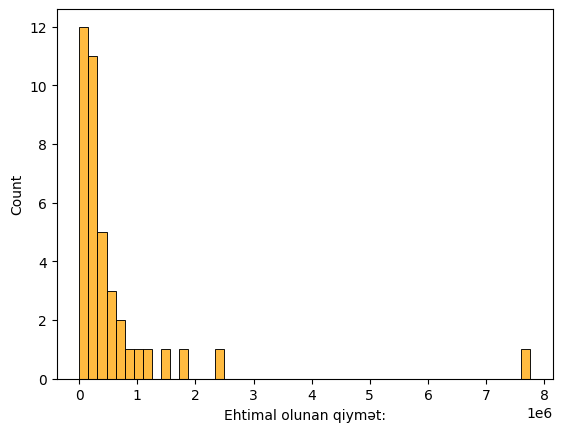

In [20]:
sns.histplot(tamamlanmislar['Ehtimal olunan qiymət:'], bins = 50, color = 'orange')

<Axes: xlabel='awardedOrganizationPrice', ylabel='Count'>

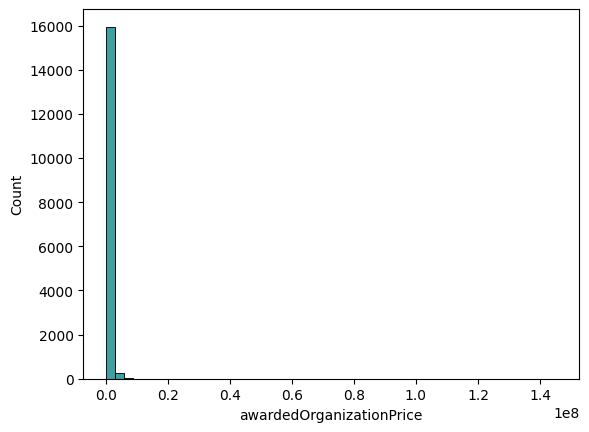

In [21]:
sns.histplot(tamamlanmislar['awardedOrganizationPrice'], bins = 50, color = 'teal')

<Axes: ylabel='awardedOrganizationPrice'>

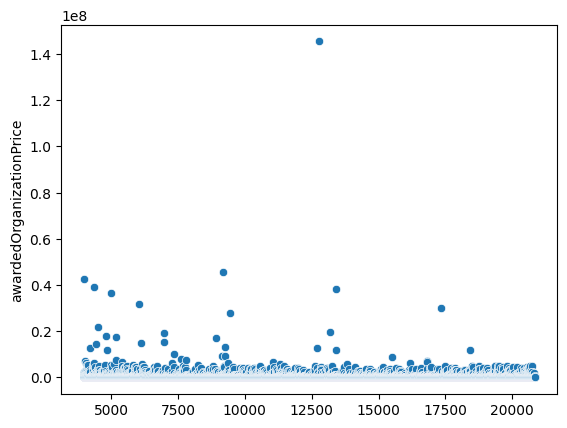

In [22]:
sns.scatterplot(tamamlanmislar['awardedOrganizationPrice'])

In [54]:
#davam eden tenderler

davamlilar = davamEden_filter(df.copy())
davamlilar

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix,iller
20839,20843,21605,305000,"""DAŞINMAZ ƏMLAKIN DÖVLƏT KADASTRI VƏ REYESTRİ""...",NaN,“Daşınmaz Əmlakın Dövlət Kadastrı və Reyestri”...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2024-04-22T19:08:30,2024-05-03T15:30:00,NaN,03.05.2024 15:30,102500.00,2024-05-03T15:30:00,2024
20840,20844,21606,304999,"""ƏSASLI TİKİNTİ VƏ TƏCHİZAT"" MƏHDUD MƏSULİYYƏT...",NaN,Mədəniyyət və yaradıcı sənayelərin inkişafının...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2024-04-22T18:42:12,2024-05-16T14:00:00,NaN,16.05.2024 14:00,833329.51,2024-05-16T14:00:00,2024
20841,20845,21607,304997,“DÖVLƏT MƏŞĞULLUQ AGENTLİYİ“ PUBLİK HÜQUQİ ŞƏXSİ,NaN,Lisenziyaların satın alınması,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2024-04-22T18:31:16,2024-05-15T15:00:00,NaN,15.05.2024 15:00,197646.12,2024-05-15T15:00:00,2024
20842,20846,21608,304993,GƏDƏBƏY RAYON İCRA HAKİMİYYƏTİ,NaN,Gədəbəy şəhərində yolların əsaslı təmiri işlər...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2024-04-22T18:18:20,2024-05-17T10:00:00,NaN,17.05.2024 10:00,971302.84,2024-05-17T10:00:00,2024
20843,20847,21609,304975,AZƏRBAYCAN RESPUBLİKASI ALİ MƏHKƏMƏSİ,NaN,Ali Məhkəmənin inzibati binasında cari təmir i...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2024-04-22T17:08:39,2024-05-02T18:00:00,NaN,02.05.2024 18:00,147583.00,2024-05-02T18:00:00,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23026,23032,23995,233565,AZƏRBAYCAN RESPUBLİKASI GƏNCLƏR VƏ İDMAN NAZİR...,NaN,Tədbirlərin keşirilməsi,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-31T16:48:52,2019-08-15T11:00:00,NaN,15.08.2019 11:00,NaN,2019-08-15T11:00:00,2019
23027,23033,23996,233520,NİZAMİ RAYON MƏNZİL KOMMUNAL TƏSƏRRÜFATI BİRLİYİ,NaN,Bakı şəhəri Nizami rayonu Bəhruz Nuriyev küçəs...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-30T15:38:15,2019-08-27T16:59:00,NaN,28.08.2019 15:00,NaN,2019-08-27T16:59:00,2019
23028,23034,23997,233480,AZƏRBAYCAN DÖVLƏT BƏDƏN TƏRBİYƏSİ VƏ İDMAN AKA...,NaN,Akademiyanın əsas binasının və İdman zalların...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-29T17:47:47,2019-08-22T15:00:00,NaN,23.08.2019 15:00,NaN,2019-08-22T15:00:00,2019
23029,23035,23998,233424,AZƏRBAYCAN MİLLİ ELMLƏR AKADEMİYASININ AKADEMİ...,NaN,Elmi-tədqiqat işləri üçün materialların alınması,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-26T10:55:14,2019-09-03T11:00:00,NaN,03.09.2019 11:00,NaN,2019-09-03T11:00:00,2019


In [24]:
#davam eden tender sayi cemi 2192dir. 

davamlilar.describe()

,Unnamed: 0.1,Unnamed: 0,ID,awardedOrganizationPrice,awardedParticipantVoen,Ehtimal olunan qiymət:
count,2192.000000,2192.000000,2192.000000,0.0,0.0,1.108000e+03
mean,21940.024635,22832.711679,289648.583942,NaN,NaN,1.372665e+06
std,633.547882,700.145052,19047.649003,NaN,NaN,4.660234e+06
min,20843.000000,21605.000000,233382.000000,NaN,NaN,4.673200e+02
25%,21392.750000,22238.750000,282363.750000,NaN,NaN,8.335953e+04
50%,21940.500000,22857.500000,300234.500000,NaN,NaN,1.992063e+05
75%,22488.250000,23443.250000,302993.000000,NaN,NaN,5.112596e+05
max,23036.000000,23999.000000,305000.000000,NaN,NaN,6.747851e+07


In [25]:
"""
1. Davam eden tender dataset "davamlilar"da unique satinalan sirket 638dir, onlardan en cox 
   "AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ"dir, cemi 54 defe cixir. 
2. Cunki bu tenderler davam eden tenderdirler, tebii ki qalib sirket "awardedParticipantName" ve teklif olunan qalib qiymet 
   "awardedOrganizationPrice" ve "finishDate" sutunlerde data yoxdurlar. 
3. tarix sutunde 413 unique tarix var, onlardan en cox davam eden tender "2024-05-06T17:00:00" tarixden cixir (15 dene). 
"""

davamlilar.describe(include='object')

,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,finishDate,publishDate,endDate,Zərflərin açılış tarixi və vaxtı:,tarix
count,2192,0,2192,0,0,2192,0,0,2192,2192,2192,2192
unique,638,0,1946,0,0,1,0,0,2191,1413,1434,1413
top,AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ,NaN,Laboratoriya şöbəsinin yenidən təşkil olunması...,NaN,NaN,davam_eden_tenderler,NaN,NaN,2024-03-04T14:24:45,2024-05-06T17:00:00,05.04.2024 17:00,2024-05-06T17:00:00
freq,54,NaN,18,NaN,NaN,2192,NaN,NaN,2,15,12,15


In [26]:
#ehtimal olunan qiymet null sayi 2192'den 1084dir (texmini 49% null)

davamlilar.isna().sum()

Unnamed: 0.1                            0
Unnamed: 0                              0
ID                                      0
buyerOrganizationName                   0
cancellationDate                     2192
eventName                               0
cancellationOption                   2192
cancellationReason                   2192
tenderin_novu                           0
awardedParticipantName               2192
awardedOrganizationPrice             2192
finishDate                           2192
publishDate                             0
endDate                                 0
awardedParticipantVoen               2192
Zərflərin açılış tarixi və vaxtı:       0
Ehtimal olunan qiymət:               1084
tarix                                   0
dtype: int64

In [27]:
davamlilar.nunique()

Unnamed: 0.1                         2192
Unnamed: 0                           2192
ID                                   2192
buyerOrganizationName                 638
cancellationDate                        0
eventName                            1946
cancellationOption                      0
cancellationReason                      0
tenderin_novu                           1
awardedParticipantName                  0
awardedOrganizationPrice                0
finishDate                              0
publishDate                          2191
endDate                              1413
awardedParticipantVoen                  0
Zərflərin açılış tarixi və vaxtı:    1434
Ehtimal olunan qiymət:               1058
tarix                                1413
dtype: int64

Text(0, 0.5, 'Tender qiymeti')

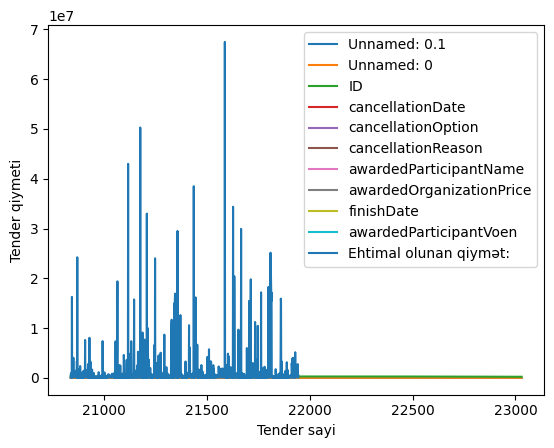

In [28]:
davamlilar.plot()
plt.xlabel('Tender sayi')
plt.ylabel('Tender qiymeti')

<Axes: xlabel='Ehtimal olunan qiymət:', ylabel='Count'>

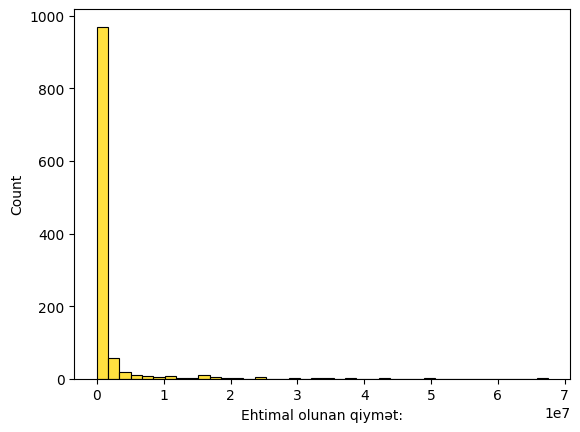

In [29]:
sns.histplot(davamlilar['Ehtimal olunan qiymət:'], bins = 40, color = 'gold')

<Axes: ylabel='Ehtimal olunan qiymət:'>

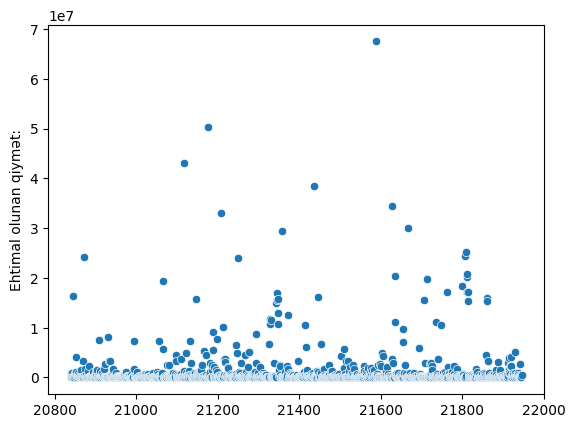

In [30]:
"""
1. Scatterplot davam eden tender data arasinda data distribution gosterir. Max deyer 67478511.8dir ve outlierdir. 
   Minimum deyer 467dir. Standard Deviation 4660233.8e qeder. 
"""
sns.scatterplot(davamlilar['Ehtimal olunan qiymət:'])

In [53]:
#legv olan tenderler

legvolanlar = legvEden_filter(df.copy())
legvolanlar

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix,iller
0,0,0,303640,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:51:29.7608426,Oğuz şəhəri X.Yunusov 87 ünvanında yerləşən i...,Tenderdə iştirak etmək üçün tender təklifi ver...,Təklif verən malgöndərənlərin sayının 3-dən az...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,29.04.2024 10:00,2500.00,2024-04-29T11:51:29.7608426,2024
1,1,1,300429,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:14:06.2847392,Oğuz şəhərində abadlıq işlərinin layihə smeta ...,Müvafiq icra hakimiyyəti orqanının qərarı əsas...,Müvafiq icra hakimiyyətinin qərarı əsasında,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,12.03.2024 09:00,3500.00,2024-04-29T11:14:06.2847392,2024
2,2,2,302742,DAXİLİ İŞLƏR NAZİRLİYİNİN BAŞ MÜHAFİZƏ İDARƏSİ,2024-04-29T10:44:23.1111078,DİN-in Baş Mühafizə İdarəsinin və tabeçiliyind...,Tenderdə iştirak etmək üçün tender təklifi ver...,DSQ 36.1.1-ci maddəsinin tələblərinə uyğun ola...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 16:00,1017458.23,2024-04-29T10:44:23.1111078,2024
3,3,3,303371,AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ,2024-04-26T17:15:15.7374777,Camaşırların yuyulması xidməti,Tenderdə iştirak etmək üçün tender təklifi ver...,Qanunun 36.1.1-ci maddəsinin tələblərinə uyğun...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 09:30,149811.80,2024-04-26T17:15:15.7374777,2024
4,4,5,302729,“DÖVLƏT MƏŞĞULLUQ AGENTLİYİ“ PUBLİK HÜQUQİ ŞƏXSİ,2024-04-26T16:55:29.660347,"İsmayıllı “DOST EVİ”, Yaradıcılıq, Sərgi və Sa...",Tenderdə iştirak etmək üçün tender təklifi ver...,Azərbaycan Respublikasının Qanununun 36.1.1-ci...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,16.04.2024 15:00,15306.18,2024-04-26T16:55:29.660347,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3977,3978,4123,232651,BAKI ŞƏHƏR MƏNZİL-KOMMUNAL TƏSƏRRÜFATI DEPARTA...,2019-06-28T07:27:41.303702,Kommunal və inşaat təyinatlı mal-materialların...,NaN,başlama tarixi səhvdi,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,07.08.2019 16:00,NaN,2019-06-28T07:27:41.303702,2019
3978,3979,4124,232638,QƏBƏLƏ RAYON İCRA HAKİMİYYƏTİ QƏBƏLƏ ŞƏHƏR İNZ...,2019-06-28T06:10:48.5896446,"1LOTQəbələ şəhərdaxili yolların,2LOT.Küçə,səki...",NaN,NaN,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,07.08.2019 14:00,NaN,2019-06-28T06:10:48.5896446,2019
3979,3980,4125,232635,QƏBƏLƏ RAYON İCRA HAKİMİYYƏTİ QƏBƏLƏ ŞƏHƏR İNZ...,2019-06-28T06:10:09.940913,"1.Qəbələ şəhərdaxili yolların,2.Küçə,səki,park...",NaN,NaN,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,07.08.2019 14:38,NaN,2019-06-28T06:10:09.940913,2019
3980,3981,4126,232634,QƏBƏLƏ RAYON İCRA HAKİMİYYƏTİ QƏBƏLƏ ŞƏHƏR İNZ...,2019-06-28T06:09:57.0380519,"1.Qəbələ şəhərdaxili yolların,2.Küçə,park və x...",NaN,NaN,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,07.08.2019 14:00,NaN,2019-06-28T06:09:57.0380519,2019


In [32]:
legvolanlar.describe()

,Unnamed: 0.1,Unnamed: 0,ID,awardedOrganizationPrice,awardedParticipantVoen,Ehtimal olunan qiymət:
count,3982.000000,3982.000000,3982.000000,0.0,0.0,1.550000e+02
mean,1991.423908,2105.132094,267851.773732,NaN,NaN,5.514224e+05
std,1149.770521,1189.052653,21305.649373,NaN,NaN,1.462397e+06
min,0.000000,0.000000,232082.000000,NaN,NaN,1.835880e+03
25%,996.250000,1082.250000,249157.000000,NaN,NaN,3.652330e+04
50%,1991.500000,2136.500000,267176.000000,NaN,NaN,1.338801e+05
75%,2986.750000,3131.750000,288560.000000,NaN,NaN,2.763718e+05
max,3982.000000,4127.000000,304900.000000,NaN,NaN,9.992113e+06


In [33]:
"""
1. Legv olan tender dataset "legvolanlar"da cemi 3982 data sayi var. 
2. Unique satinalan sirket 710 idi, onlarda en cox "AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ" idi (173).
3. Legv oluma kategoriyasi sutun "cancellationOption"de ve sebebi sutun "cancellationReason"de 5 ve 3134 unique deyer var, 
   onlardan en cax kategoriyasi "Tenderdə iştirak etmək üçün tender təklifi ver..." 1253dur ve sebebi 
   "Müsabiqəyə təklif verən malgöndərənlərin sayı ..." en coxdur, 58 dene. 
4. Legv datasetde tebii ki "awardedParticipantName, awardedOrganizationPrice, finishDate, publishDate, endDate, awardedParticipantVoen" 
   sutunler olmamalidirler, datasetde de yoxdurlar.                
"""

legvolanlar.describe(include='object')

,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,finishDate,publishDate,endDate,Zərflərin açılış tarixi və vaxtı:,tarix
count,3982,3982,3982,2094,3956,3982,0,0,0,0,3982,3982
unique,710,3982,3277,5,3134,1,0,0,0,0,2844,3982
top,AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ,2024-04-29T11:51:29.7608426,Dəftərxana və təsərrüfat malları,Tenderdə iştirak etmək üçün tender təklifi ver...,Müsabiqəyə təklif verən malgöndərənlərin sayı ...,legv_edilmis,NaN,NaN,NaN,NaN,-,2024-04-29T11:51:29.7608426
freq,173,1,14,1253,58,3982,NaN,NaN,NaN,NaN,53,1


In [34]:
legvolanlar.isna().sum()

Unnamed: 0.1                            0
Unnamed: 0                              0
ID                                      0
buyerOrganizationName                   0
cancellationDate                        0
eventName                               0
cancellationOption                   1888
cancellationReason                     26
tenderin_novu                           0
awardedParticipantName               3982
awardedOrganizationPrice             3982
finishDate                           3982
publishDate                          3982
endDate                              3982
awardedParticipantVoen               3982
Zərflərin açılış tarixi və vaxtı:       0
Ehtimal olunan qiymət:               3827
tarix                                   0
dtype: int64

In [35]:
legvolanlar.nunique()

Unnamed: 0.1                         3982
Unnamed: 0                           3982
ID                                   3982
buyerOrganizationName                 710
cancellationDate                     3982
eventName                            3277
cancellationOption                      5
cancellationReason                   3134
tenderin_novu                           1
awardedParticipantName                  0
awardedOrganizationPrice                0
finishDate                              0
publishDate                             0
endDate                                 0
awardedParticipantVoen                  0
Zərflərin açılış tarixi və vaxtı:    2844
Ehtimal olunan qiymət:                141
tarix                                3982
dtype: int64

<Axes: xlabel='Ehtimal olunan qiymət:', ylabel='Count'>

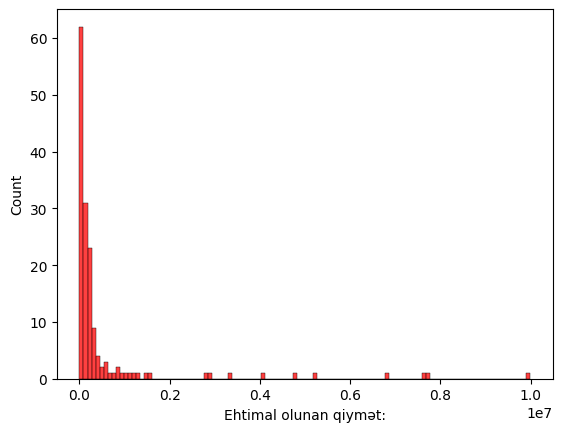

In [36]:
sns.histplot(legvolanlar['Ehtimal olunan qiymət:'], color = 'red')

In [37]:
legvolanlar['Ehtimal olunan qiymət:'].std()

1462396.5601527838

<Axes: ylabel='Ehtimal olunan qiymət:'>

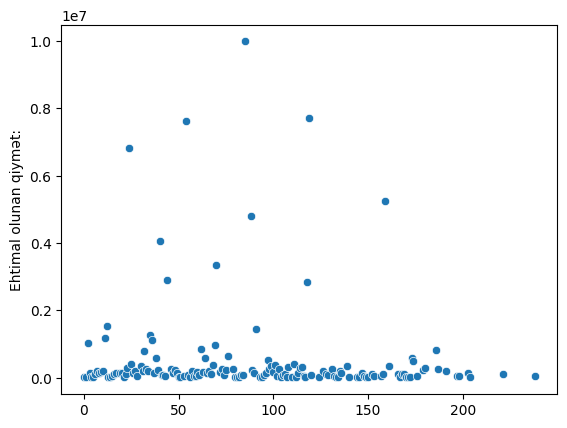

In [38]:
"""
1. Scatterplotda maximum Ehtimal olunan qiymet 9992113.07 idi, o da outlier. Minimum qiymet 1835 idi. 
   Standard deviation 1462396.6'ya qeder. 
"""
sns.scatterplot(legvolanlar['Ehtimal olunan qiymət:'])

count    4.000000e+01
mean     6.190947e+05
std      1.266908e+06
min      7.000000e+03
25%      1.105542e+05
50%      2.686272e+05
75%      5.561845e+05
max      7.760729e+06
Name: Ehtimal olunan qiymət:, dtype: float64


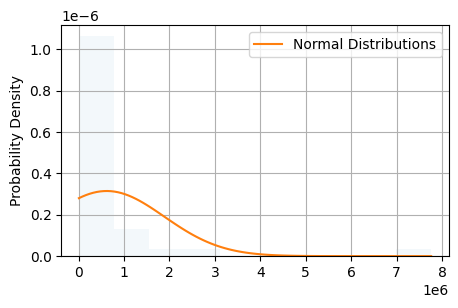

count    1.108000e+03
mean     1.372665e+06
std      4.660234e+06
min      4.673200e+02
25%      8.335953e+04
50%      1.992063e+05
75%      5.112596e+05
max      6.747851e+07
Name: Ehtimal olunan qiymət:, dtype: float64


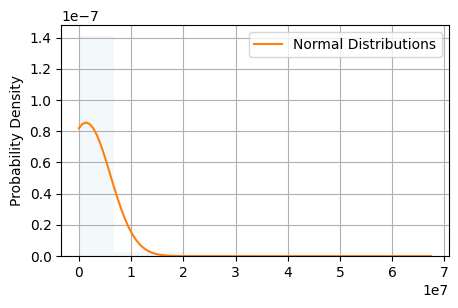

count    1.550000e+02
mean     5.514224e+05
std      1.462397e+06
min      1.835880e+03
25%      3.652330e+04
50%      1.338801e+05
75%      2.763718e+05
max      9.992113e+06
Name: Ehtimal olunan qiymət:, dtype: float64


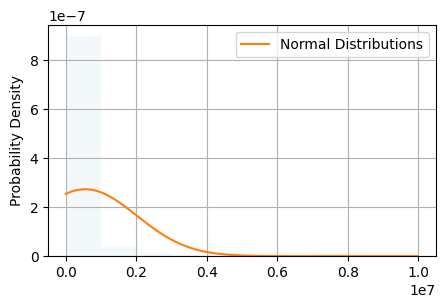

In [39]:
#Birlikde tamamlanmis, davam eden ve legv olan ehtimal olunan qiymetlerin Normal Distribution.

qiymetler = [tamamlanmislar['Ehtimal olunan qiymət:'], davamlilar['Ehtimal olunan qiymət:'], legvolanlar['Ehtimal olunan qiymət:']]

def normal_distribution(column):

    norDist = column.describe()
    print(norDist)

    plt.figure(figsize=(5,3))
    n, bins, patches = plt.hist(column, density = True, alpha = 0.05)

    mu = norDist['mean']
    sigma = norDist['std']
    x = np.linspace(bins.min(), bins.max(), 100)
    y = norm.pdf(x, mu, sigma)

    plt.plot(x,y, label = "Normal Distributions")
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(True)
    plt.show()

for i in qiymetler:
    normal_distribution(i)


In [40]:
#Tarixler uzre

In [41]:
df['tarix'].value_counts().sort_values(ascending=True).head(20)

tarix
2022-09-02T15:26:44            1
2024-04-26T16:43:08.4975378    1
2024-04-26T10:45:29.9422155    1
2024-04-25T19:14:34.6220687    1
2024-04-25T19:09:58.2373955    1
2024-04-22T10:37:21.2104516    1
2024-04-25T19:06:59.3261336    1
2024-04-25T18:27:37.270775     1
2024-04-25T18:06:17.9284159    1
2024-04-25T18:05:55.9237543    1
2024-04-25T18:02:39.7495771    1
2024-04-25T18:01:30.5189041    1
2024-04-25T18:00:56.9984848    1
2024-04-25T18:00:20.0015306    1
2024-04-25T14:23:57.9496174    1
2024-04-25T18:44:27.5174314    1
2024-04-19T16:48:37.2132105    1
2024-04-19T16:46:21.2180796    1
2024-04-26T16:44:16.7693778    1
2024-04-26T16:55:29.660347     1
Name: count, dtype: int64

In [42]:
#butun datasetde sonuncu tarix, il = 2024, ay = May
df['tarix'].min()

'2019-06-27T10:57:30.1571849'

In [43]:
#butun datasetde sonuncu tarix, il = 2024, ay = May
df['tarix'].max()

'2024-05-27T14:00:00'

In [44]:
#Iller uzre bir ayri sutun yaratmaq

def iller_uzre(data, dateCol = 'tarix', iller = 'iller'): 
    data[iller] = pd.to_datetime(data[dateCol], format='ISO8601').dt.year

    return data

df = iller_uzre(df.copy())
df

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix,iller
0,0,0,303640,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:51:29.7608426,Oğuz şəhəri X.Yunusov 87 ünvanında yerləşən i...,Tenderdə iştirak etmək üçün tender təklifi ver...,Təklif verən malgöndərənlərin sayının 3-dən az...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,29.04.2024 10:00,2500.00,2024-04-29T11:51:29.7608426,2024
1,1,1,300429,OĞUZ RAYON İCRA HAKİMİYYƏTİ,2024-04-29T11:14:06.2847392,Oğuz şəhərində abadlıq işlərinin layihə smeta ...,Müvafiq icra hakimiyyəti orqanının qərarı əsas...,Müvafiq icra hakimiyyətinin qərarı əsasında,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,12.03.2024 09:00,3500.00,2024-04-29T11:14:06.2847392,2024
2,2,2,302742,DAXİLİ İŞLƏR NAZİRLİYİNİN BAŞ MÜHAFİZƏ İDARƏSİ,2024-04-29T10:44:23.1111078,DİN-in Baş Mühafizə İdarəsinin və tabeçiliyind...,Tenderdə iştirak etmək üçün tender təklifi ver...,DSQ 36.1.1-ci maddəsinin tələblərinə uyğun ola...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 16:00,1017458.23,2024-04-29T10:44:23.1111078,2024
3,3,3,303371,AZƏRBAYCAN RESPUBLİKASI DÖVLƏT SƏRHƏD XİDMƏTİ,2024-04-26T17:15:15.7374777,Camaşırların yuyulması xidməti,Tenderdə iştirak etmək üçün tender təklifi ver...,Qanunun 36.1.1-ci maddəsinin tələblərinə uyğun...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,24.04.2024 09:30,149811.80,2024-04-26T17:15:15.7374777,2024
4,4,5,302729,“DÖVLƏT MƏŞĞULLUQ AGENTLİYİ“ PUBLİK HÜQUQİ ŞƏXSİ,2024-04-26T16:55:29.660347,"İsmayıllı “DOST EVİ”, Yaradıcılıq, Sərgi və Sa...",Tenderdə iştirak etmək üçün tender təklifi ver...,Azərbaycan Respublikasının Qanununun 36.1.1-ci...,legv_edilmis,NaN,NaN,NaN,NaN,NaN,NaN,16.04.2024 15:00,15306.18,2024-04-26T16:55:29.660347,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23026,23032,23995,233565,AZƏRBAYCAN RESPUBLİKASI GƏNCLƏR VƏ İDMAN NAZİR...,NaN,Tədbirlərin keşirilməsi,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-31T16:48:52,2019-08-15T11:00:00,NaN,15.08.2019 11:00,NaN,2019-08-15T11:00:00,2019
23027,23033,23996,233520,NİZAMİ RAYON MƏNZİL KOMMUNAL TƏSƏRRÜFATI BİRLİYİ,NaN,Bakı şəhəri Nizami rayonu Bəhruz Nuriyev küçəs...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-30T15:38:15,2019-08-27T16:59:00,NaN,28.08.2019 15:00,NaN,2019-08-27T16:59:00,2019
23028,23034,23997,233480,AZƏRBAYCAN DÖVLƏT BƏDƏN TƏRBİYƏSİ VƏ İDMAN AKA...,NaN,Akademiyanın əsas binasının və İdman zalların...,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-29T17:47:47,2019-08-22T15:00:00,NaN,23.08.2019 15:00,NaN,2019-08-22T15:00:00,2019
23029,23035,23998,233424,AZƏRBAYCAN MİLLİ ELMLƏR AKADEMİYASININ AKADEMİ...,NaN,Elmi-tədqiqat işləri üçün materialların alınması,NaN,NaN,davam_eden_tenderler,NaN,NaN,NaN,2019-07-26T10:55:14,2019-09-03T11:00:00,NaN,03.09.2019 11:00,NaN,2019-09-03T11:00:00,2019


In [45]:
#butun datasetde minimum il = 2019
#butun datasetde sonuncu il = 2024

min_il = df['iller'].min()
max_il = df['iller'].max()

print(min_il, ' ', max_il)

2019   2024


In [46]:
#Iller sutunde null deyerler yoxdur 

df['iller'].isna().sum()

0

In [47]:
#En cox data 2023cu ilden gelir. (6623 dene)
#En az, 2019cu ilden gelir. (960)
#Cari ilde 1842 dene var heleki. 

df['iller'].value_counts()

iller
2023    6623
2022    5433
2021    4579
2020    3594
2024    1842
2019     960
Name: count, dtype: int64

Text(0, 0.5, 'Cemi tender sayi')

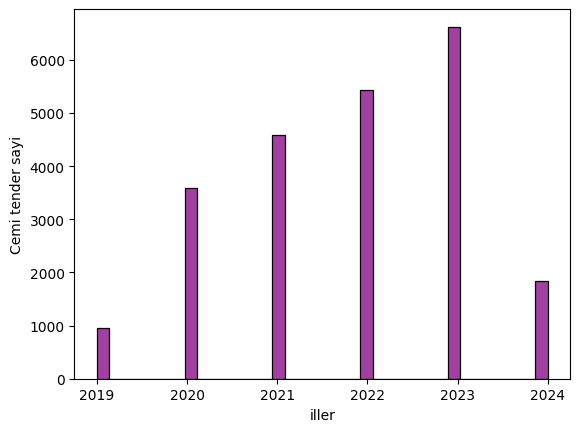

In [49]:
#Iller uzre histogram 
#Illerine gore histogram positiv trend/ascend gosterir 

sns.histplot(df['iller'], color = 'purple')
plt.ylabel('Cemi tender sayi')

In [69]:
novlerine_gore = df.groupby("iller")["tenderin_novu"].value_counts().unstack(fill_value=0)
novlerine_gore

tenderin_novu,davam_eden_tenderler,legv_edilmis,tamamlanmis_tenderler
iller,,,
2019,44,310,606
2020,120,678,2796
2021,110,840,3629
2022,263,672,4498
2023,513,1230,4880
2024,1142,252,448


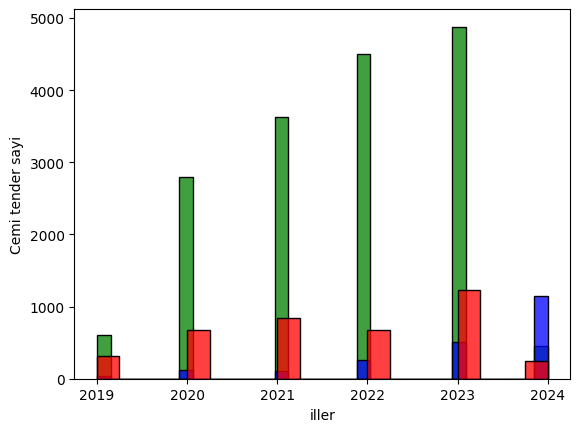

In [56]:
"""
1. Illerine gore tamamlanmis, davam eden ve legv olan tender datasetlerin histogramlar.
2. Tamamlanmis tenderin sayi en coxdur ve positiv trend gosterir her il. 
3. En cox davam eden tenderler. Her ilden dava meden tender var ve postiv trend ile her il qalxir.
4. Cari ilde davam tenderler coxdur, tamamlanmis tenderden.   
"""

datalar = [tamamlanmislar, davamlilar, legvolanlar]

def iller_uzre_histogram(data, il = 'iller'): 
    if pd.Series(data[il]).eq(tamamlanmislar[il]).any(): 
        sns.histplot(data[il], color = 'green')
    
    elif pd.Series(data[il]).eq(davamlilar[il]).any(): 
        sns.histplot(data[il], color = 'blue')
        
    elif pd.Series(data[il]).eq(legvolanlar[il]).any():
        sns.histplot(data[il], color = 'red')
        plt.xlabel('iller')
        plt.ylabel('Cemi tender sayi')

for data in datalar:
    iller_uzre_histogram(data)

In [57]:
"""
1. Ilerine gore butun sutunlerde olan null deyerler bir yerde
2. "awardedParticipantVOEN"den basqa "Ehtimal olunan qiymət:" sutunde null coxdur. 
"""

ilde_null = df.groupby('iller').apply(lambda x: x.isnull().sum(), include_groups=False)
ilde_null


,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix
iller,,,,,,,,,,,,,,,,,,
2019,0,0,0,0,650,0,960,676,0,372,377,354,916,916,960,0,960,0
2020,0,0,0,0,2916,0,3594,2916,0,857,857,798,3474,3474,3594,0,3594,0
2021,0,0,0,0,3739,0,4579,3739,0,1068,1068,950,4469,4469,4579,0,4579,0
2022,0,0,0,0,4761,0,4821,4761,0,1112,1112,935,5170,5170,5433,0,5433,0
2023,0,0,0,0,5393,0,5393,5393,0,1948,1948,1743,6110,6110,6623,0,6623,0
2024,0,0,0,0,1590,0,1590,1590,0,1406,1406,1394,700,700,1842,0,539,0


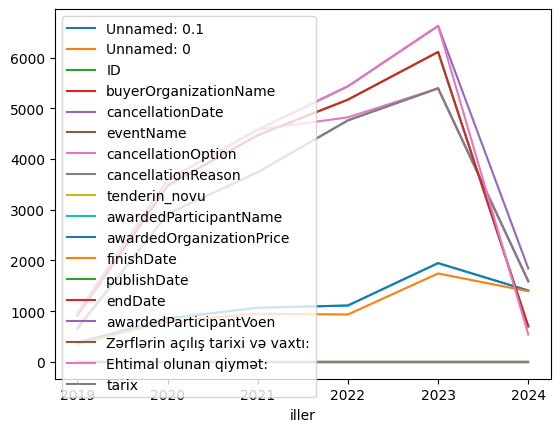

In [58]:
"""
1. En cox null deyerler 2023cu ilden cixir. En az 2019cu ilden.
2. Her il trend qalxir/positivtrend gosterir. 
"""
ilde_null.plot()
plt.legend(loc = 'upper left')


In [59]:
#tamamlanmis tender arasinda illerine gore null deyerler

tamamlanmisde_null = tamamlanmislar.groupby('iller').apply(lambda x: x.isnull().sum(), include_groups=False)
tamamlanmisde_null

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix
iller,,,,,,,,,,,,,,,,,,
2019,0,0,0,0,606,0,606,606,0,18,23,0,606,606,606,0,606,0
2020,0,0,0,0,2796,0,2796,2796,0,59,59,0,2796,2796,2796,0,2796,0
2021,0,0,0,0,3629,0,3629,3629,0,118,118,0,3629,3629,3629,0,3629,0
2022,0,0,0,0,4498,0,4498,4498,0,177,177,0,4498,4498,4498,0,4498,0
2023,0,0,0,0,4880,0,4880,4880,0,205,205,0,4880,4880,4880,0,4880,0
2024,0,0,0,0,448,0,448,448,0,12,12,0,448,448,448,0,408,0


<Axes: xlabel='iller'>

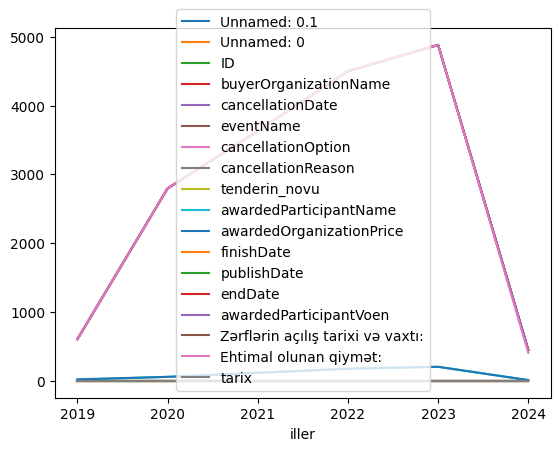

In [60]:
#Tebii ki yuxarida yazan kimi, tamamlanmis tenderlerde ehtimal olunan qiymeti en cox null value verir, 
#2023cu ilde maximum sayi

tamamlanmisde_null.plot()

In [61]:
#Illerine gore davam eden tender arasinda null deyerler
davamedende_null = davamlilar.groupby('iller').apply(lambda x: x.isnull().sum(), include_groups=False)
davamedende_null

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix
iller,,,,,,,,,,,,,,,,,,
2019,0,0,0,0,44,0,44,44,0,44,44,44,0,0,44,0,44,0
2020,0,0,0,0,120,0,120,120,0,120,120,120,0,0,120,0,120,0
2021,0,0,0,0,110,0,110,110,0,110,110,110,0,0,110,0,110,0
2022,0,0,0,0,263,0,263,263,0,263,263,263,0,0,263,0,263,0
2023,0,0,0,0,513,0,513,513,0,513,513,513,0,0,513,0,513,0
2024,0,0,0,0,1142,0,1142,1142,0,1142,1142,1142,0,0,1142,0,34,0


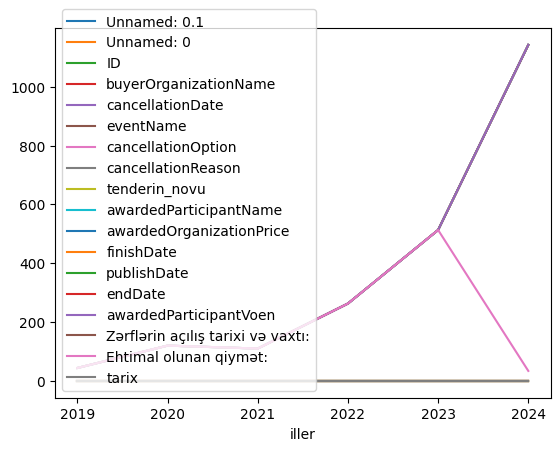

In [62]:
"""
1. Yuxarida yazan kimi davam eden tender datasetinde "cancellationOption" ve "awardedParticipantVoen" null sayi en coxdur. 
2. Ehtimal olunan qiymeti null sayi qalxirdi 2023cu ile qeder, en cox null sayi 2023cu ilden gelir. 
3. En az Ehtimal olunan qiymeti null sayi cari ilden gelir. 
"""
davamedende_null.plot()
plt.legend(loc='lower left')

In [63]:
#Illerine gore legv olan tenderler null sayi
legvolanda_null = legvolanlar.groupby('iller').apply(lambda x: x.isnull().sum(), include_groups=False)
legvolanda_null

,Unnamed: 0.1,Unnamed: 0,ID,buyerOrganizationName,cancellationDate,eventName,cancellationOption,cancellationReason,tenderin_novu,awardedParticipantName,awardedOrganizationPrice,finishDate,publishDate,endDate,awardedParticipantVoen,Zərflərin açılış tarixi və vaxtı:,Ehtimal olunan qiymət:,tarix
iller,,,,,,,,,,,,,,,,,,
2019,0,0,0,0,0,0,310,26,0,310,310,310,310,310,310,0,310,0
2020,0,0,0,0,0,0,678,0,0,678,678,678,678,678,678,0,678,0
2021,0,0,0,0,0,0,840,0,0,840,840,840,840,840,840,0,840,0
2022,0,0,0,0,0,0,60,0,0,672,672,672,672,672,672,0,672,0
2023,0,0,0,0,0,0,0,0,0,1230,1230,1230,1230,1230,1230,0,1230,0
2024,0,0,0,0,0,0,0,0,0,252,252,252,252,252,252,0,97,0


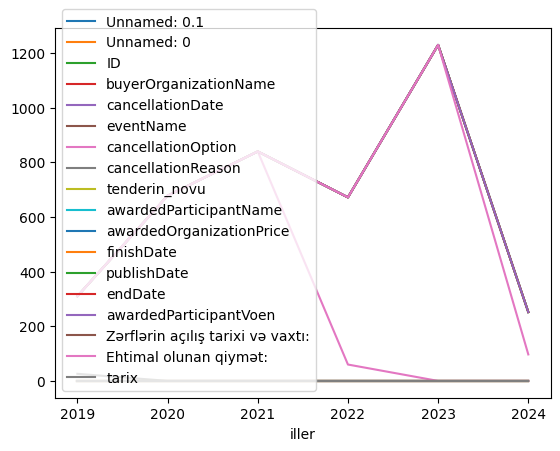

In [64]:
"""
1. Legv olan tender datasetinde illerine gore Ehtimal olunan qiymeti sayi 2019-2021 illerde qalxib
   ve 2022ci ilde dusub asagi, sonra en cox qalxib 2023cu ile, maximum sayi report olunub. 
2. "cancellationOption" qalxirdi 2021ci ile qeder sonra daimi asagi dusub trend.
3. En az cemi null value plotdan davam eden tenderden gelir, en cox tamamlanmis tenderlerden gosterir,
   ortada legv olan tender dataseti. 
"""

legvolanda_null.plot()
plt.legend(loc='lower left')